# Mental Health in Tech Survey — EDA Capstone Project

**Project Type:** Exploratory Data Analysis (EDA)  
**Contribution:** Individual  
**Dataset:** Mental Health in Tech Survey (2014)

### Project Summary
This project analyzes survey responses about attitudes toward mental health and the frequency of mental-health-related experiences in the technology workplace. The analysis focuses on respondent demographics, treatment-seeking behavior, family history, workplace environment, mental-health benefits, awareness of care options, remote work, and attitudes toward discussing mental health at work.

The objective is to identify meaningful patterns and relationships in the survey data and convert them into practical workplace insights. The original dataset description states that the survey measures attitudes toward mental health and the frequency of mental health disorders in the tech workplace. It also suggests exploring geographic variation and possible predictors of mental-health-related outcomes.

This notebook follows a structured **UBM approach**:
- **U — Univariate Analysis:** one variable at a time
- **B — Bivariate Analysis:** relationships between two variables
- **M — Multivariate Analysis:** relationships involving multiple variables

The notebook is designed to execute from top to bottom without manual edits after the CSV is placed in the working directory.

## Problem Statement

The survey contains demographic, workplace, and mental-health-related responses. However, the raw data includes missing values, inconsistent gender labels, and extreme age values that need to be handled before analysis.

The problem is to clean and explore the survey data, understand major patterns in mental-health treatment and workplace attitudes, and identify relationships that can support evidence-based workplace recommendations.

### Business Objective
1. Understand the overall distribution of mental-health treatment responses.
2. Examine how family history and workplace factors relate to treatment-seeking.
3. Understand employee awareness of mental-health benefits and care options.
4. Explore attitudes toward discussing mental health with coworkers, supervisors, and employers.
5. Identify patterns that may help organizations improve awareness, accessibility, and workplace support.

In [1]:
# Import required libraries
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load dataset
DATA_PATH = "survey.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully: {df.shape[0]:,} rows and {df.shape[1]} columns")
display(df.head())

Dataset loaded successfully: 1,259 rows and 27 columns


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


## 1. Know Your Data

In [3]:
# Dataset shape and first view
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
display(df.head())
display(df.tail())

Rows: 1259
Columns: 27


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
1254,2015-09-12 11:17:21,26,male,United Kingdom,NaN,No,No,Yes,NaN,26-100,No,Yes,No,No,No,No,Don't know,Somewhat easy,No,No,Some of them,Some of them,No,No,Don't know,No,NaN
1255,2015-09-26 01:07:35,32,Male,United States,IL,No,Yes,Yes,Often,26-100,Yes,Yes,Yes,Yes,No,No,Yes,Somewhat difficult,No,No,Some of them,Yes,No,No,Yes,No,NaN
1256,2015-11-07 12:36:58,34,male,United States,CA,No,Yes,Yes,Sometimes,More than 1000,No,Yes,Yes,Yes,No,No,Don't know,Somewhat difficult,Yes,Yes,No,No,No,No,No,No,NaN
1257,2015-11-30 21:25:06,46,f,United States,NC,No,No,No,NaN,100-500,Yes,Yes,No,Yes,No,No,Don't know,Don't know,Yes,No,No,No,No,No,No,No,NaN
1258,2016-02-01 23:04:31,25,Male,United States,IL,No,Yes,Yes,Sometimes,26-100,No,No,Yes,Yes,No,No,Yes,Don't know,Maybe,No,Some of them,No,No,No,Don't know,No,NaN


In [4]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

In [5]:
# Duplicate values
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [6]:
# Missing values
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "Missing %": missing_pct
})

display(missing_summary[missing_summary["Missing Values"] > 0])

,Missing Values,Missing %
comments,1095,86.97
state,515,40.91
work_interfere,264,20.97
self_employed,18,1.43


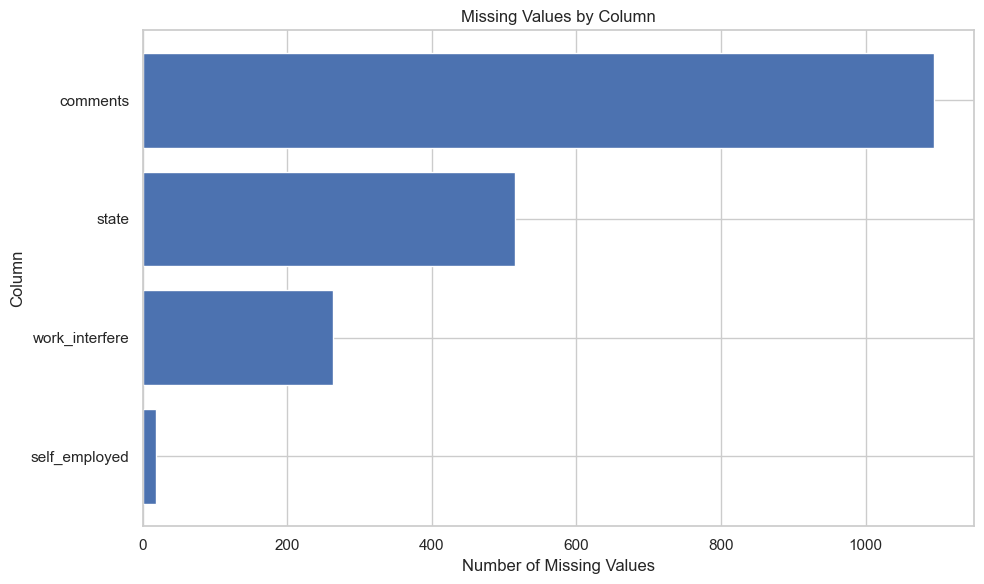

In [7]:
# Visualize missing values
missing_plot = missing_summary[missing_summary["Missing Values"] > 0].sort_values("Missing Values", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(missing_plot.index, missing_plot["Missing Values"])
plt.xlabel("Number of Missing Values")
plt.ylabel("Column")
plt.title("Missing Values by Column")
plt.tight_layout()
plt.show()

### What did we learn about the dataset?

The dataset contains 1,259 survey responses and 27 variables. The variables cover respondent demographics, employment characteristics, workplace mental-health support, and attitudes toward mental health.

The main data-quality issues are missing values in fields such as `comments`, `state`, and `work_interfere`, plus inconsistent values in the `Gender` column. The `Age` field also contains unrealistic extreme values, so age should be validated before using it for analysis.

These issues are handled in the data-wrangling section rather than silently dropping large portions of the survey.

## 2. Understanding Your Variables

In [8]:
# Column names
print("Dataset columns:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")

Dataset columns:
01. Timestamp
02. Age
03. Gender
04. Country
05. state
06. self_employed
07. family_history
08. treatment
09. work_interfere
10. no_employees
11. remote_work
12. tech_company
13. benefits
14. care_options
15. wellness_program
16. seek_help
17. anonymity
18. leave
19. mental_health_consequence
20. phys_health_consequence
21. coworkers
22. supervisor
23. mental_health_interview
24. phys_health_interview
25. mental_vs_physical
26. obs_consequence
27. comments


In [9]:
# Numerical description
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Timestamp,1259,1246,2014-08-27 12:31:41,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1259.0,NaN,NaN,NaN,79428148.311358,2818299442.981968,-1726.0,27.0,31.0,36.0,99999999999.0
Gender,1259,49,Male,615,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,1259,48,United States,751,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,744,45,CA,138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
self_employed,1241,2,No,1095,NaN,NaN,NaN,NaN,NaN,NaN,NaN
family_history,1259,2,No,767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
treatment,1259,2,Yes,637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_interfere,995,4,Sometimes,465,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_employees,1259,6,6-25,290,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables Description

- **Age:** respondent age.
- **Gender:** respondent's reported gender.
- **Country / state:** geographic information.
- **self_employed:** whether the respondent is self-employed.
- **family_history:** whether the respondent reports a family history of mental illness.
- **treatment:** whether the respondent has sought treatment for a mental-health condition.
- **work_interfere:** whether a mental-health condition interferes with work.
- **no_employees:** company size category.
- **remote_work:** whether the respondent works remotely at least 50% of the time.
- **tech_company:** whether the employer is primarily a technology company/organization.
- **benefits / care_options / wellness_program / seek_help / anonymity / leave:** workplace mental-health support and accessibility variables.
- **mental_health_consequence / phys_health_consequence:** perceived consequences of discussing health issues with an employer.
- **coworkers / supervisor / mental_health_interview:** willingness to discuss mental health in different workplace situations.
- **mental_vs_physical:** whether mental health is perceived as being taken as seriously as physical health.
- **obs_consequence:** whether the respondent has observed negative workplace consequences for coworkers with mental-health conditions.
- **comments:** optional open-ended notes.

In [10]:
# Unique values for each variable
unique_values = {col: df[col].dropna().unique().tolist() for col in df.columns}
for col, values in unique_values.items():
    print(f"\n{col}: {len(values)} unique non-null values")
    print(values[:15], "..." if len(values) > 15 else "")


Timestamp: 1246 unique non-null values
['2014-08-27 11:29:31', '2014-08-27 11:29:37', '2014-08-27 11:29:44', '2014-08-27 11:29:46', '2014-08-27 11:30:22', '2014-08-27 11:31:22', '2014-08-27 11:31:50', '2014-08-27 11:32:05', '2014-08-27 11:32:39', '2014-08-27 11:32:43', '2014-08-27 11:32:44', '2014-08-27 11:32:49', '2014-08-27 11:33:23', '2014-08-27 11:33:26', '2014-08-27 11:33:57'] ...

Age: 53 unique non-null values
[37, 44, 32, 31, 33, 35, 39, 42, 23, 29, 36, 27, 46, 41, 34] ...

Gender: 49 unique non-null values
['Female', 'M', 'Male', 'male', 'female', 'm', 'Male-ish', 'maile', 'Trans-female', 'Cis Female', 'F', 'something kinda male?', 'Cis Male', 'Woman', 'f'] ...

Country: 48 unique non-null values
['United States', 'Canada', 'United Kingdom', 'Bulgaria', 'France', 'Portugal', 'Netherlands', 'Switzerland', 'Poland', 'Australia', 'Germany', 'Russia', 'Mexico', 'Brazil', 'Slovenia'] ...

state: 45 unique non-null values
['IL', 'IN', 'TX', 'TN', 'MI', 'OH', 'CA', 'CT', 'MD', 'NY',

## 3. Data Wrangling

In [11]:
# Create an analysis-ready copy
data = df.copy()

# Remove exact duplicate rows if any exist.
data = data.drop_duplicates().copy()

# Convert timestamp to datetime.
data["Timestamp"] = pd.to_datetime(data["Timestamp"], errors="coerce")

# Keep realistic working-age values for age analysis.
# The raw survey contains extreme invalid age values.
data["Age_clean"] = data["Age"].where(data["Age"].between(18, 100))

# Standardize gender into broad analytical groups.
def standardize_gender(value):
    if pd.isna(value):
        return "Unknown"
    s = str(value).strip().lower()

    female_terms = [
        "female", "woman", "femail", "cis-female", "cis female",
        "trans-female", "trans woman"
    ]
    male_terms = [
        "male", "man", "cis male", "cis man", "male-ish",
        "mail", "mal", "malr", "maile", "msle", "guy"
    ]

    if any(term in s for term in female_terms):
        return "Female"
    if any(term in s for term in male_terms):
        return "Male"
    return "Other"

data["Gender_group"] = data["Gender"].apply(standardize_gender)

# Fill only categorical analysis fields where "Missing/Unknown" is analytically useful.
for col in ["self_employed", "work_interfere", "state"]:
    data[col] = data[col].fillna("Unknown")

print("Data wrangling completed.")
print("Rows after duplicate removal:", len(data))
print("Invalid/extreme age values set to NaN:", data["Age_clean"].isna().sum())

Data wrangling completed.
Rows after duplicate removal: 1259
Invalid/extreme age values set to NaN: 8


In [12]:
# Verify cleaned data
print("Duplicate rows after cleaning:", data.duplicated().sum())
print("Valid age range:", data["Age_clean"].min(), "to", data["Age_clean"].max())
display(data[["Age", "Age_clean", "Gender", "Gender_group"]].head(10))

Duplicate rows after cleaning: 0
Valid age range: 18.0 to 72.0


,Age,Age_clean,Gender,Gender_group
0,37,37.0,Female,Female
1,44,44.0,M,Other
2,32,32.0,Male,Male
3,31,31.0,Male,Male
4,31,31.0,Male,Male
5,33,33.0,Male,Male
6,35,35.0,Female,Female
7,39,39.0,M,Other
8,42,42.0,Female,Female
9,23,23.0,Male,Male


### What manipulations were done and why?

1. Exact duplicate rows were removed so repeated records do not distort counts.
2. `Timestamp` was converted to a datetime type.
3. Unrealistic `Age` values were converted to missing values for age-based analysis instead of being treated as real ages.
4. Gender labels were standardized into broad groups (`Male`, `Female`, `Other`) to reduce fragmentation caused by inconsistent raw labels.
5. Selected missing categorical values were labeled `Unknown` where that preserves the fact that the respondent did not provide an answer.

The original columns are retained in `data`; cleaned helper columns are added for analysis.

## 4. Data Visualization, Storytelling & Experimenting with Charts

In [13]:
# Helper function for consistent chart formatting
def finish_chart(title, xlabel="", ylabel="", rotation=0):
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.show()

### Chart 1 — Age Distribution

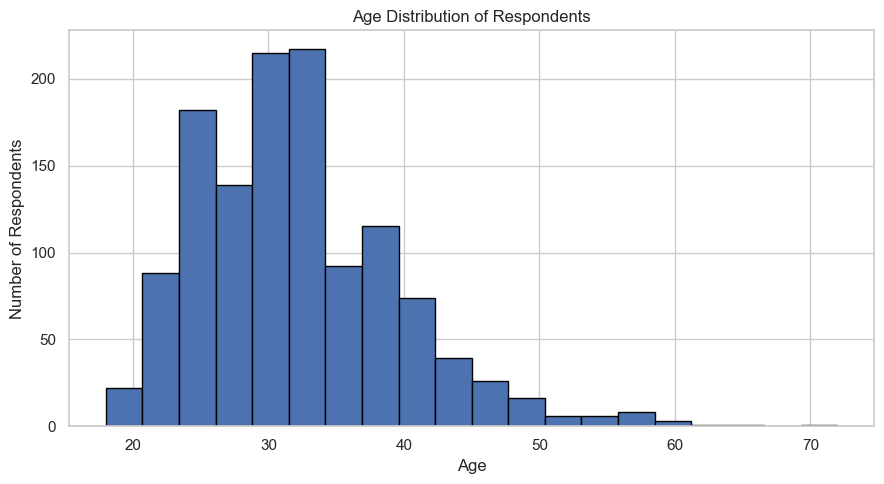

In [14]:
plt.figure(figsize=(9, 5))
plt.hist(data["Age_clean"].dropna(), bins=20, edgecolor="black")
finish_chart("Age Distribution of Respondents", "Age", "Number of Respondents")

**1. Why did I pick this chart?**

Histogram is suitable for understanding the distribution and concentration of a numerical variable such as age.

**2. What insights were found?**

The cleaned age distribution is concentrated around the late 20s and 30s. Extreme raw age values were excluded from this visualization because they are not realistic ages.

**3. Business impact / limitation**

Understanding respondent demographics helps place the remaining workplace findings in context; however, age distribution alone does not establish a causal relationship with mental health.

### Chart 2 — Gender Distribution

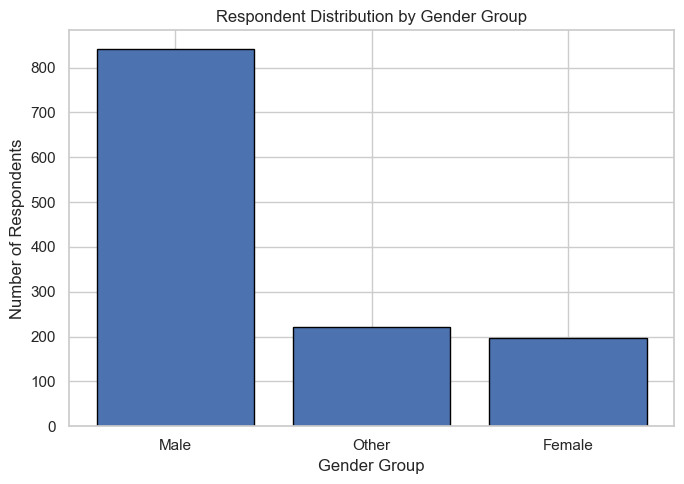

In [15]:
gender_counts = data["Gender_group"].value_counts()
plt.figure(figsize=(7, 5))
plt.bar(gender_counts.index, gender_counts.values, edgecolor="black")
finish_chart("Respondent Distribution by Gender Group", "Gender Group", "Number of Respondents")

**1. Why did I pick this chart?**

A bar chart clearly compares the number of respondents across categorical gender groups.

**2. What insights were found?**

The survey responses are dominated by the Male group, followed by Female and Other groups after standardization.

**3. Business impact / limitation**

Segmenting results by gender can reveal differences in responses, while the uneven sample sizes should be considered when interpreting percentages.

### Chart 3 — Top Countries

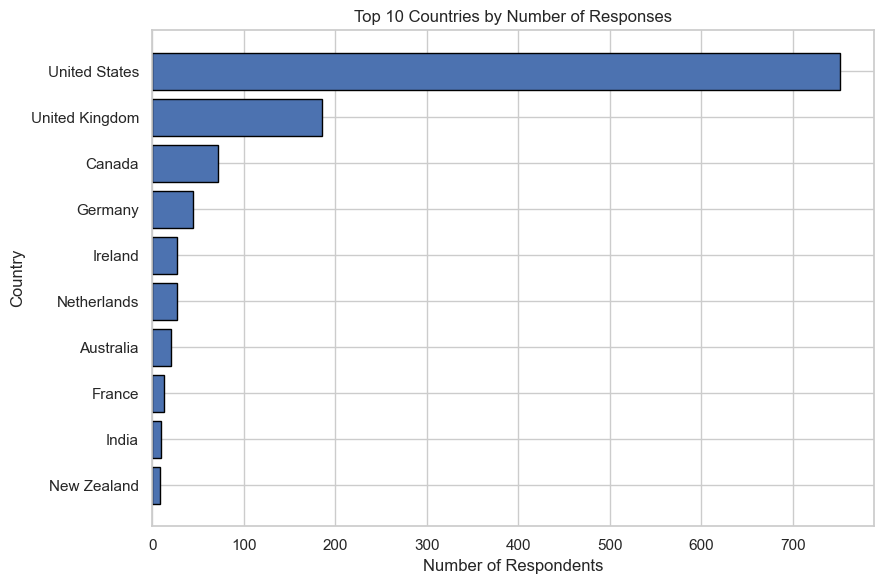

In [16]:
country_counts = data["Country"].value_counts().head(10).sort_values()
plt.figure(figsize=(9, 6))
plt.barh(country_counts.index, country_counts.values, edgecolor="black")
finish_chart("Top 10 Countries by Number of Responses", "Number of Respondents", "Country")

**1. Why did I pick this chart?**

A horizontal bar chart is effective for comparing many country categories while keeping labels readable.

**2. What insights were found?**

The United States contributes the largest share of responses, while the remaining top countries have substantially fewer observations.

**3. Business impact / limitation**

Geographic concentration matters because country-level comparisons can be strongly affected by unequal sample sizes.

### Chart 4 — Treatment Distribution

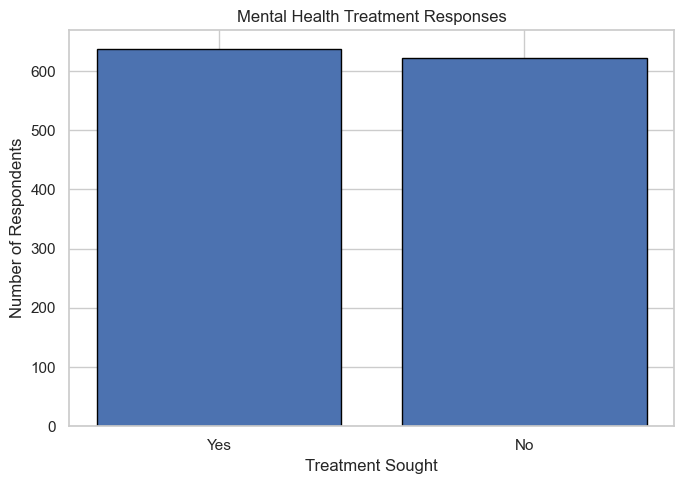

In [17]:
treatment_counts = data["treatment"].value_counts()
plt.figure(figsize=(7, 5))
plt.bar(treatment_counts.index, treatment_counts.values, edgecolor="black")
finish_chart("Mental Health Treatment Responses", "Treatment Sought", "Number of Respondents")

**1. Why did I pick this chart?**

A bar chart makes the Yes/No treatment split easy to compare.

**2. What insights were found?**

The dataset has a near-even split between respondents who reported seeking treatment and those who did not.

**3. Business impact / limitation**

This provides a useful baseline for examining which demographic and workplace factors are associated with different treatment responses.

### Chart 5 — Family History

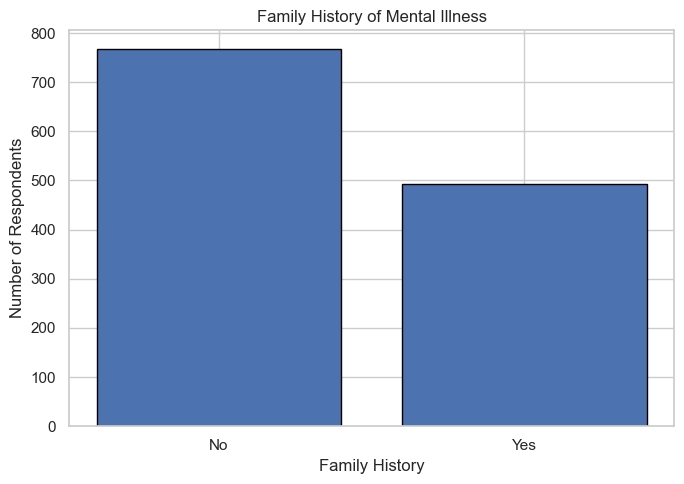

In [18]:
family_counts = data["family_history"].value_counts()
plt.figure(figsize=(7, 5))
plt.bar(family_counts.index, family_counts.values, edgecolor="black")
finish_chart("Family History of Mental Illness", "Family History", "Number of Respondents")

**1. Why did I pick this chart?**

A categorical count chart shows how common reported family history is in the sample.

**2. What insights were found?**

Most respondents reported no family history, while a substantial group reported a family history of mental illness.

**3. Business impact / limitation**

Family history can be examined as an important contextual variable when studying treatment responses, without treating it as proof of causation.

### Chart 6 — Remote Work

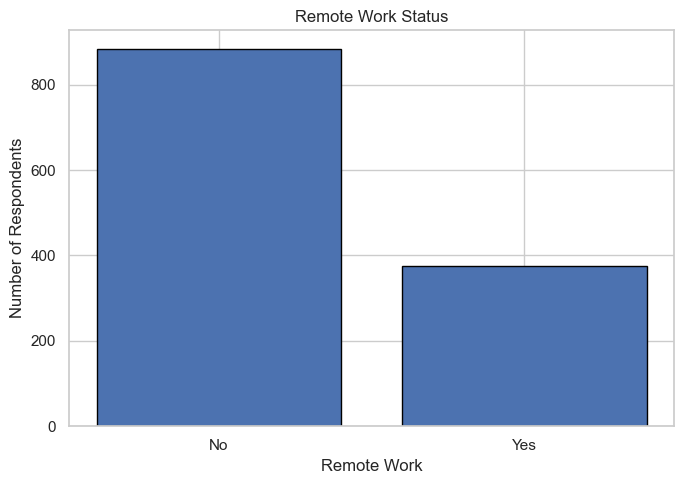

In [19]:
remote_counts = data["remote_work"].value_counts()
plt.figure(figsize=(7, 5))
plt.bar(remote_counts.index, remote_counts.values, edgecolor="black")
finish_chart("Remote Work Status", "Remote Work", "Number of Respondents")

**1. Why did I pick this chart?**

A bar chart provides a simple comparison of remote and non-remote respondents.

**2. What insights were found?**

Most respondents reported not working remotely at least 50% of the time.

**3. Business impact / limitation**

Work arrangement can be considered when organizations design mental-health support, although this descriptive result alone does not show that remote work causes different outcomes.

### Chart 7 — Tech Company

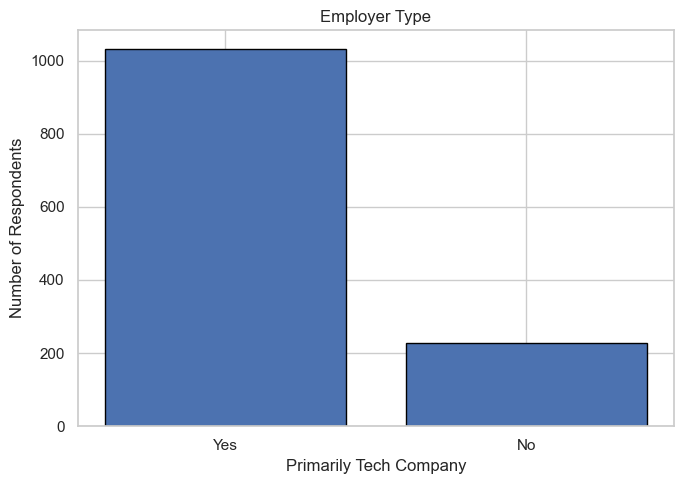

In [20]:
tech_counts = data["tech_company"].value_counts()
plt.figure(figsize=(7, 5))
plt.bar(tech_counts.index, tech_counts.values, edgecolor="black")
finish_chart("Employer Type", "Primarily Tech Company", "Number of Respondents")

**1. Why did I pick this chart?**

A bar chart clearly displays the employer-type distribution.

**2. What insights were found?**

The majority of respondents reported working for an employer primarily identified as a technology company/organization.

**3. Business impact / limitation**

This confirms that the sample is strongly connected to the technology workplace described by the survey.

### Chart 8 — Company Size

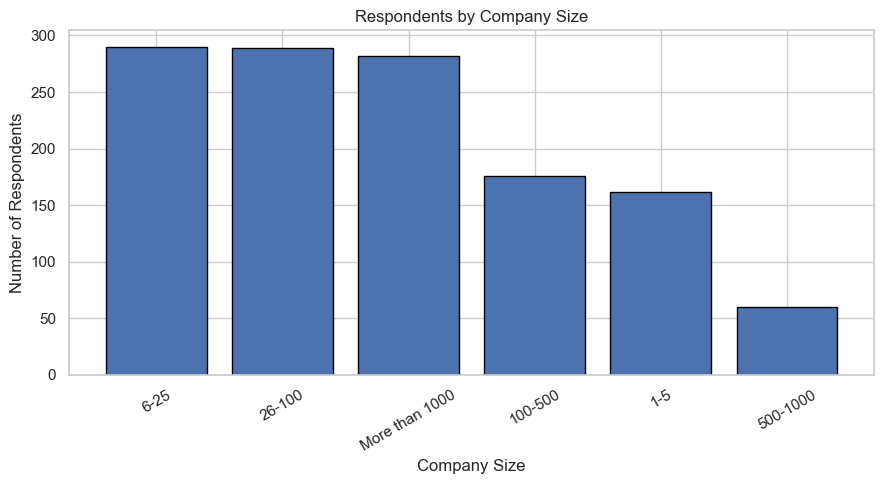

In [21]:
size_counts = data["no_employees"].value_counts()
plt.figure(figsize=(9, 5))
plt.bar(size_counts.index, size_counts.values, edgecolor="black")
finish_chart("Respondents by Company Size", "Company Size", "Number of Respondents", rotation=30)

**1. Why did I pick this chart?**

A bar chart allows comparison of company-size categories.

**2. What insights were found?**

Responses are spread across several organization-size categories, allowing workplace support to be examined across different company structures.

**3. Business impact / limitation**

Company size may matter because the availability of formal benefits and leave policies can differ between smaller and larger organizations.

### Chart 9 — Mental Health Benefits

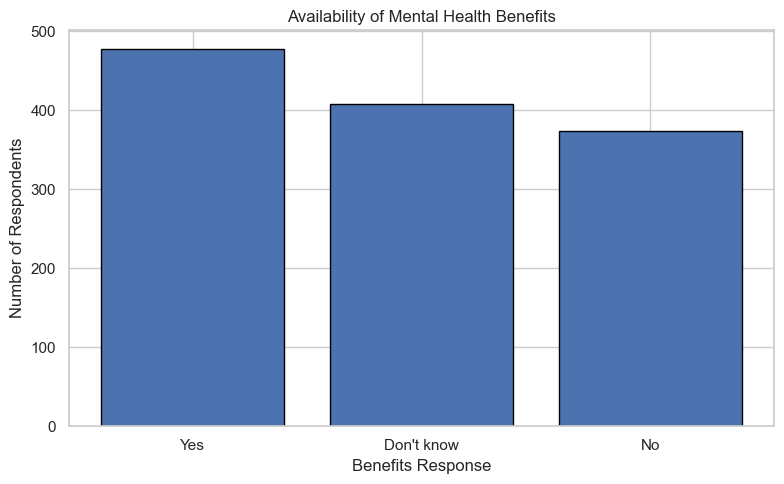

In [22]:
benefit_counts = data["benefits"].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(benefit_counts.index, benefit_counts.values, edgecolor="black")
finish_chart("Availability of Mental Health Benefits", "Benefits Response", "Number of Respondents")

**1. Why did I pick this chart?**

A categorical bar chart directly compares Yes, No, and Don't know responses.

**2. What insights were found?**

A notable portion of respondents either reported no mental-health benefits or did not know whether benefits were available.

**3. Business impact / limitation**

Low awareness can reduce effective access even when benefits exist, so communication about available resources is an actionable workplace consideration.

### Chart 10 — Care Options

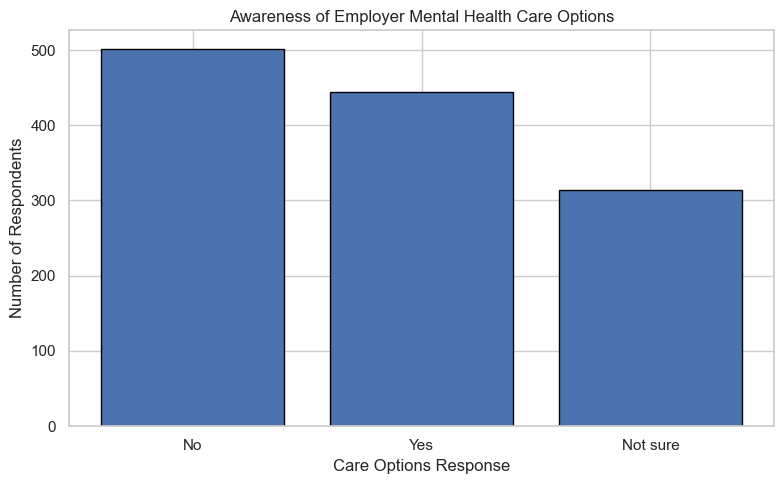

In [23]:
care_counts = data["care_options"].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(care_counts.index, care_counts.values, edgecolor="black")
finish_chart("Awareness of Employer Mental Health Care Options", "Care Options Response", "Number of Respondents")

**1. Why did I pick this chart?**

The bar chart compares awareness categories directly.

**2. What insights were found?**

Responses are divided among Yes, No, and Not sure, showing that awareness of care options is not universal.

**3. Business impact / limitation**

Organizations can use clear communication and simple access pathways to improve awareness of existing support.

### Chart 11 — Wellness Program

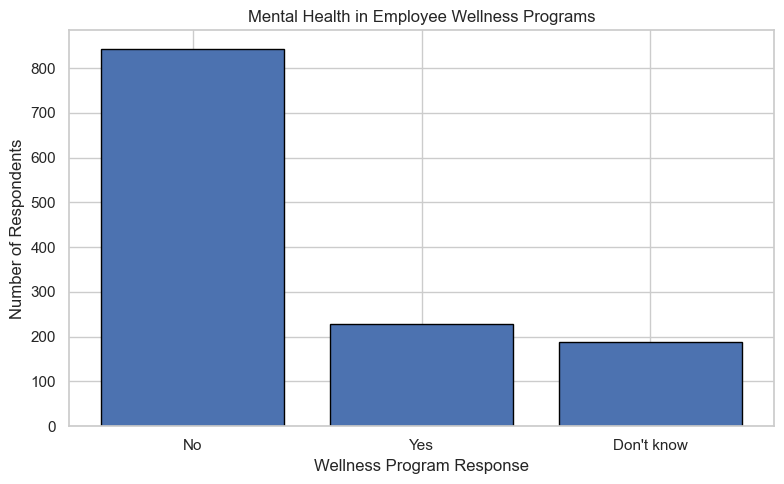

In [24]:
wellness_counts = data["wellness_program"].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(wellness_counts.index, wellness_counts.values, edgecolor="black")
finish_chart("Mental Health in Employee Wellness Programs", "Wellness Program Response", "Number of Respondents")

**1. Why did I pick this chart?**

A bar chart is appropriate for comparing the three response categories.

**2. What insights were found?**

Most respondents reported that mental health had not been discussed as part of an employee wellness program, while fewer reported Yes.

**3. Business impact / limitation**

Integrating mental-health awareness into wellness communication may increase visibility of support resources.

### Chart 12 — Work Interference

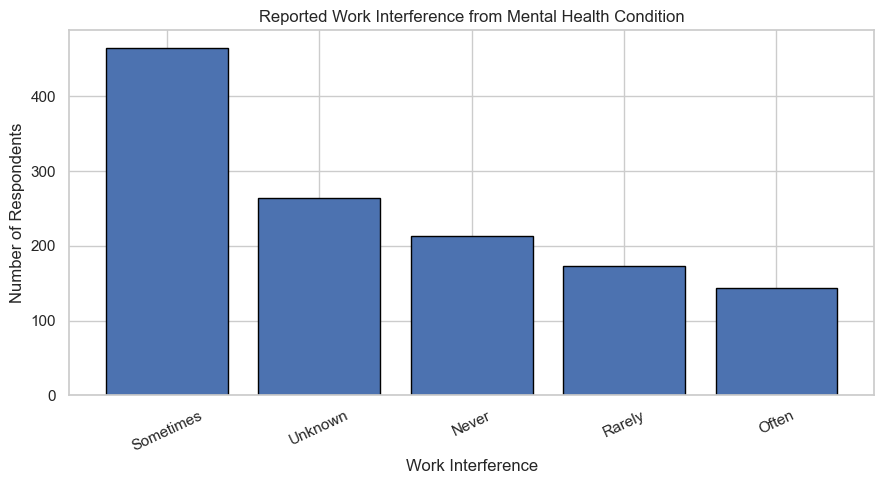

In [25]:
work_counts = data["work_interfere"].value_counts()
plt.figure(figsize=(9, 5))
plt.bar(work_counts.index, work_counts.values, edgecolor="black")
finish_chart("Reported Work Interference from Mental Health Condition", "Work Interference", "Number of Respondents", rotation=25)

**1. Why did I pick this chart?**

A bar chart shows the distribution of the ordered categorical responses.

**2. What insights were found?**

Among respondents who answered this question, work interference varies from Never to Often, with missing/unknown responses also present.

**3. Business impact / limitation**

This highlights why workplace support should account for different levels of impact rather than assuming one experience applies to every employee.

### Chart 13 — Treatment by Family History

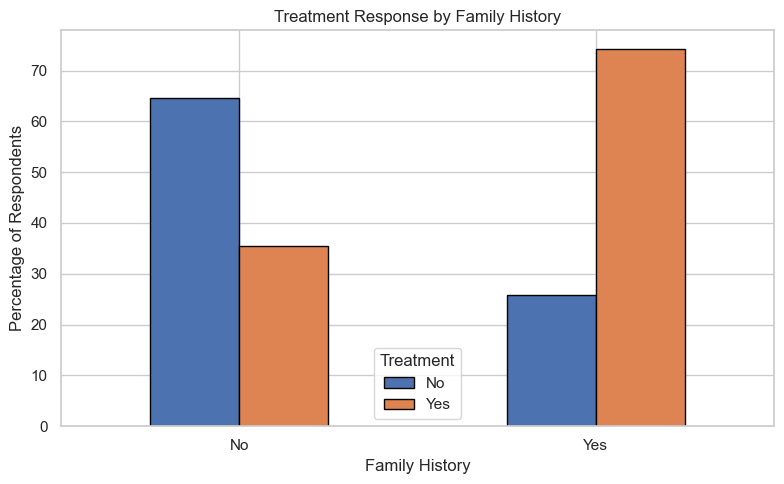

In [26]:
ct = pd.crosstab(data["family_history"], data["treatment"], normalize="index") * 100
ct.plot(kind="bar", figsize=(8, 5), edgecolor="black")
plt.ylabel("Percentage of Respondents")
plt.xlabel("Family History")
plt.title("Treatment Response by Family History")
plt.xticks(rotation=0)
plt.legend(title="Treatment")
plt.tight_layout()
plt.show()

**1. Why did I pick this chart?**

A normalized stacked/side-by-side categorical comparison is useful because it compares treatment proportions within each family-history group.

**2. What insights were found?**

Respondents reporting a family history have a much higher treatment rate than respondents reporting no family history.

**3. Business impact / limitation**

This relationship can help identify an important segment for further analysis, but it should be interpreted as an association rather than a causal effect.

### Chart 14 — Treatment by Gender

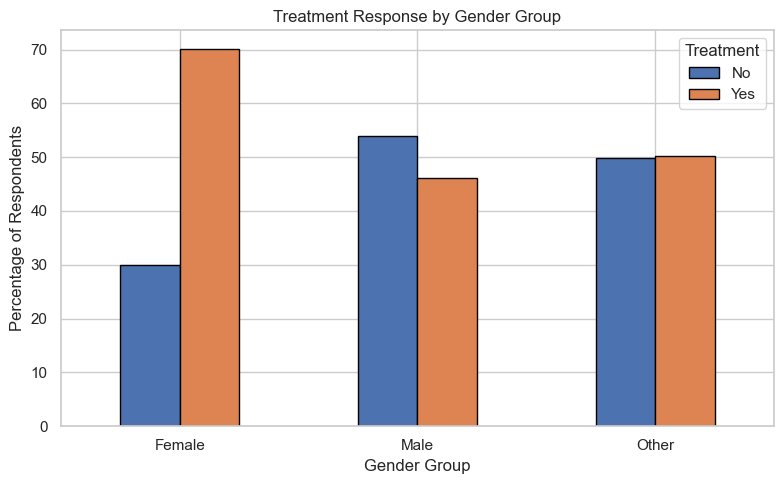

In [27]:
ct = pd.crosstab(data["Gender_group"], data["treatment"], normalize="index") * 100
ct.plot(kind="bar", figsize=(8, 5), edgecolor="black")
plt.ylabel("Percentage of Respondents")
plt.xlabel("Gender Group")
plt.title("Treatment Response by Gender Group")
plt.xticks(rotation=0)
plt.legend(title="Treatment")
plt.tight_layout()
plt.show()

**1. Why did I pick this chart?**

Normalized bars make treatment proportions comparable even when group sizes differ.

**2. What insights were found?**

Treatment response proportions differ across the standardized gender groups, although the Other group is much smaller than the Male and Female groups.

**3. Business impact / limitation**

The result can support further segmentation, but small subgroup size limits strong conclusions for the Other category.

### Chart 15 — Treatment by Remote Work

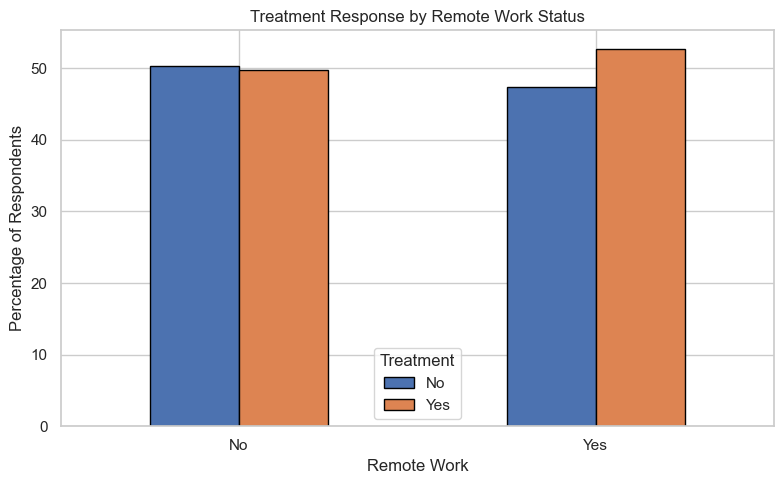

In [28]:
ct = pd.crosstab(data["remote_work"], data["treatment"], normalize="index") * 100
ct.plot(kind="bar", figsize=(8, 5), edgecolor="black")
plt.ylabel("Percentage of Respondents")
plt.xlabel("Remote Work")
plt.title("Treatment Response by Remote Work Status")
plt.xticks(rotation=0)
plt.legend(title="Treatment")
plt.tight_layout()
plt.show()

**1. Why did I pick this chart?**

A normalized comparison tests whether treatment proportions differ between remote and non-remote respondents.

**2. What insights were found?**

The treatment proportions differ between the remote-work groups, but the difference is descriptive and does not establish that work arrangement causes the difference.

**3. Business impact / limitation**

This can inform questions for deeper workplace research about accessibility and work arrangements.

### Chart 16 — Treatment by Tech Company

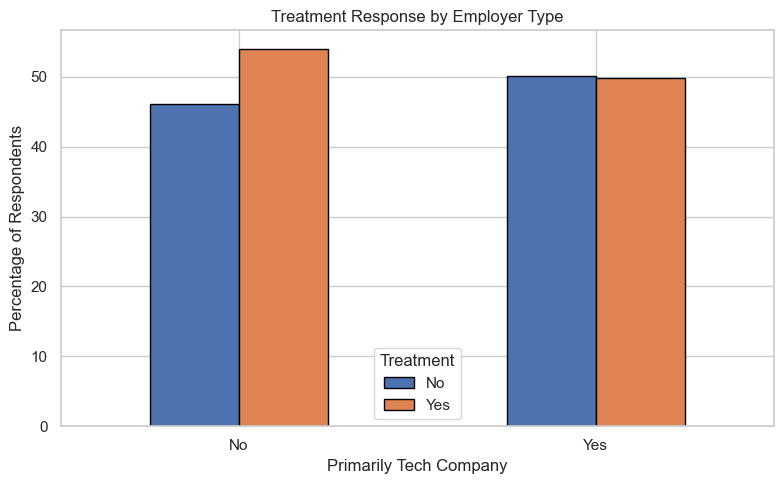

In [29]:
ct = pd.crosstab(data["tech_company"], data["treatment"], normalize="index") * 100
ct.plot(kind="bar", figsize=(8, 5), edgecolor="black")
plt.ylabel("Percentage of Respondents")
plt.xlabel("Primarily Tech Company")
plt.title("Treatment Response by Employer Type")
plt.xticks(rotation=0)
plt.legend(title="Treatment")
plt.tight_layout()
plt.show()

**1. Why did I pick this chart?**

A normalized categorical comparison shows treatment proportions within employer-type groups.

**2. What insights were found?**

Treatment proportions vary between respondents at primarily tech and non-tech organizations.

**3. Business impact / limitation**

The finding may help frame organization-type differences for further investigation, while recognizing the sample imbalance between groups.

### Chart 17 — Treatment by Company Size

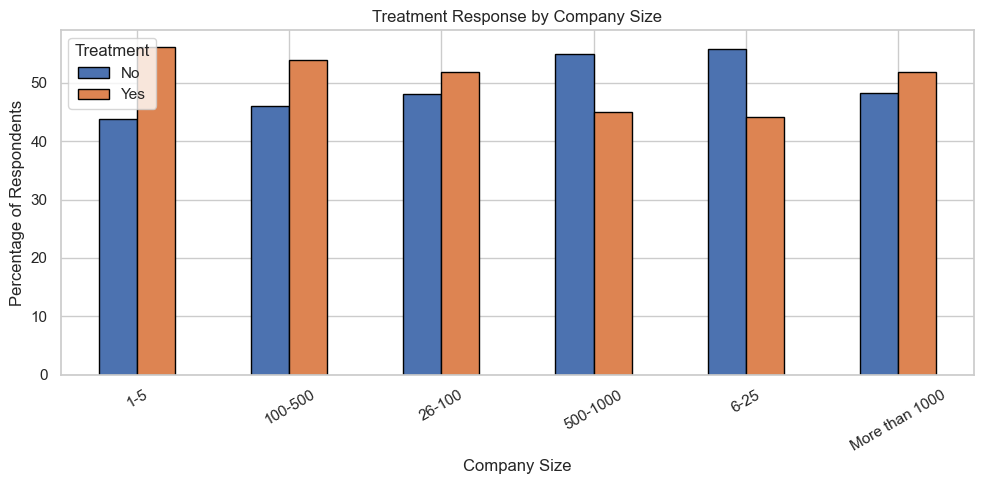

In [30]:
ct = pd.crosstab(data["no_employees"], data["treatment"], normalize="index") * 100
ct.plot(kind="bar", figsize=(10, 5), edgecolor="black")
plt.ylabel("Percentage of Respondents")
plt.xlabel("Company Size")
plt.title("Treatment Response by Company Size")
plt.xticks(rotation=30)
plt.legend(title="Treatment")
plt.tight_layout()
plt.show()

**1. Why did I pick this chart?**

Normalized bars allow treatment proportions to be compared across company-size categories.

**2. What insights were found?**

Treatment response proportions vary across organization-size categories, suggesting that workplace structure may be worth examining further.

**3. Business impact / limitation**

Organizations can investigate whether resource availability and policy communication differ by company size, without assuming company size itself causes treatment behavior.

### Chart 18 — Mental Health Consequence vs Treatment

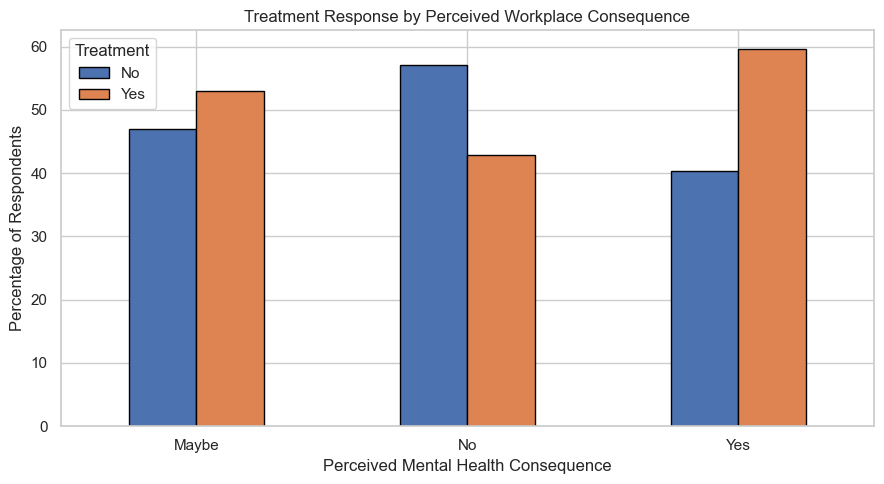

In [31]:
ct = pd.crosstab(data["mental_health_consequence"], data["treatment"], normalize="index") * 100
ct.plot(kind="bar", figsize=(9, 5), edgecolor="black")
plt.ylabel("Percentage of Respondents")
plt.xlabel("Perceived Mental Health Consequence")
plt.title("Treatment Response by Perceived Workplace Consequence")
plt.xticks(rotation=0)
plt.legend(title="Treatment")
plt.tight_layout()
plt.show()

**1. Why did I pick this chart?**

A normalized comparison helps examine whether treatment responses vary with perceived negative consequences of discussing mental health.

**2. What insights were found?**

The treatment distribution differs across respondents who selected Yes, No, or Maybe regarding negative workplace consequences.

**3. Business impact / limitation**

This highlights the importance of psychological safety and clear workplace communication, while the survey alone cannot establish direction of causality.

### Chart 19 — Mental vs Physical Health

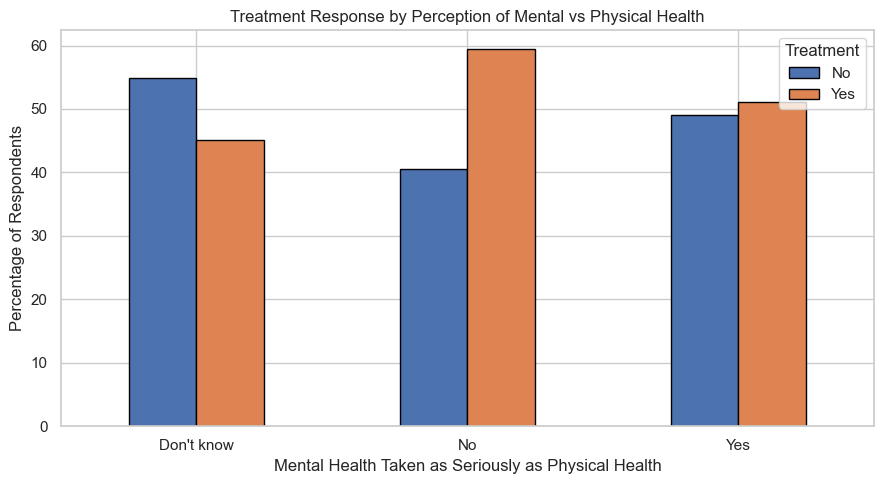

In [32]:
ct = pd.crosstab(data["mental_vs_physical"], data["treatment"], normalize="index") * 100
ct.plot(kind="bar", figsize=(9, 5), edgecolor="black")
plt.ylabel("Percentage of Respondents")
plt.xlabel("Mental Health Taken as Seriously as Physical Health")
plt.title("Treatment Response by Perception of Mental vs Physical Health")
plt.xticks(rotation=0)
plt.legend(title="Treatment")
plt.tight_layout()
plt.show()

**1. Why did I pick this chart?**

A normalized comparison connects workplace perception with treatment response.

**2. What insights were found?**

Treatment proportions differ among respondents who believe mental health is treated as seriously as physical health, those who disagree, and those who are unsure.

**3. Business impact / limitation**

Perceived workplace culture is an important area for organizations to monitor through employee feedback and communication.

### Chart 20 — Multivariate Heatmap

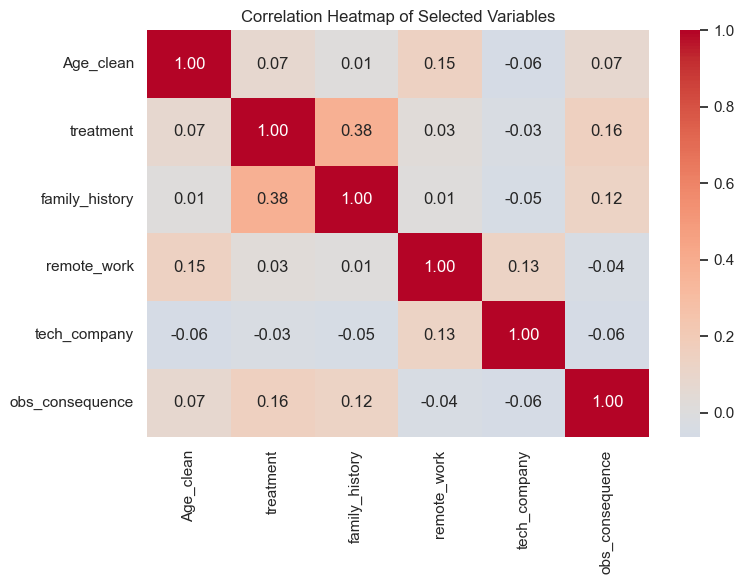

In [33]:
# Encode selected binary/categorical variables for a compact correlation view.
heat_data = data[[
    "Age_clean", "treatment", "family_history", "remote_work",
    "tech_company", "obs_consequence"
]].copy()

binary_map = {"Yes": 1, "No": 0}
for col in ["treatment", "family_history", "remote_work", "tech_company", "obs_consequence"]:
    heat_data[col] = heat_data[col].map(binary_map)

corr = heat_data.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Selected Variables")
plt.tight_layout()
plt.show()

**1. Why did I pick this chart?**

A correlation heatmap summarizes pairwise linear associations among selected numerical/binary variables in one view.

**2. What insights were found?**

The strongest visible relationship is between treatment and family history, consistent with the earlier bivariate analysis. Other relationships are comparatively smaller.

**3. Business impact / limitation**

Correlation can help prioritize variables for deeper analysis, but correlation is not evidence of causation and binary encodings should be interpreted carefully.

## 5. Solution to Business Objective

Based on the exploratory analysis, the following evidence-based actions can be considered:

1. **Improve awareness of available mental-health benefits.** A meaningful number of respondents selected `No` or `Don't know` for benefits, indicating that availability and awareness are separate issues.
2. **Make care options easy to understand.** The care-options responses show that not every respondent knows where to seek support.
3. **Increase visibility of mental-health discussions in wellness programs.** The wellness-program distribution suggests that mental health was not consistently discussed.
4. **Protect psychological safety.** Responses about possible negative consequences of discussing mental health should be monitored because fear of workplace consequences can affect willingness to communicate.
5. **Use employee segmentation carefully.** Family history shows a clear association with treatment response and can be used as a variable for further analysis, but it should not be treated as a causal explanation.
6. **Investigate differences by workplace structure.** Remote work, employer type, and company size show differences in treatment responses that can be explored further with larger or more recent datasets.

### Important limitation
This is a 2014 survey dataset. The analysis is descriptive and based on survey responses, so the results should not be interpreted as causal or automatically representative of every technology workplace today.

# Conclusion

The Mental Health in Tech Survey provides a useful view of how employees reported treatment, workplace support, and attitudes toward mental health.

The analysis shows that treatment responses are associated with several contextual factors, particularly family history. It also shows gaps in awareness of mental-health benefits and care options, along with limited discussion of mental health through wellness programs in the survey responses.

The most practical takeaway is that workplace support should not focus only on whether a benefit exists. Employees also need to know what resources are available, how to access them, and whether they can use them without fear of negative workplace consequences.

The next step would be to build an interactive **Streamlit dashboard** from the cleaned dataset so users can explore these patterns by country, gender group, company size, remote-work status, and other available variables.